# Débruitage d'un signal de capteur de procédé bruité avec PROC LOESS

## Résumé analytique

Un capteur de température de chambre de four sur une ligne de fabrication est échantillonné une fois par seconde pendant le démarrage, de sorte que chaque relevé mélange un régime thermique transitoire non linéaire lent (une montée en température rapide, un dépassement transitoire, puis un retour vers la consigne de 300 °C) avec un bruit de mesure important. Ce notebook utilise **PROC LOESS** pour récupérer le signal sous-jacent de façon non paramétrique. Sur le relevé de 100 échantillons, l'AICC a sélectionné un paramètre de lissage de 0,08 (8 paramètres équivalents) ; la courbe obtenue suit fidèlement le signal latent, laissant des résidus avec un écart-type de 3,10 °C — essentiellement le bruit de 4 °C que nous avons injecté, moins la variance expliquée par l'ajustement. Par rapport à la vérité terrain connue, l'estimation LOESS réduit l'erreur quadratique moyenne (EQM) de 14,77 (données brutes) à 6,63, et une étape SCORE rééchantillonne le signal débruité sur une grille de surveillance uniforme pour la maîtrise statistique des procédés (MSP) en aval.

## Sources de données

| Jeu de données | Lignes | Variables | Description |
|---------|------|-----------|-------------|
| `sensor` | 100 | `t` (secondes écoulées, 0–99), `temp` (température de chambre observée, °C), `truth` (signal latent sans bruit, pour validation uniquement) | Relevé synthétique de capteur de four, un échantillon par seconde. Le signal latent est une montée en température rapide vers une consigne de 300 °C avec un dépassement amorti culminant près de t = 28 (~295 °C), qui redescend puis se stabilise vers la consigne ; le `temp` observé ajoute un bruit de mesure gaussien (écart-type ~4 °C). |
| `grid` | 60 | `t` (grille de surveillance uniforme 0–99) | Grille temporelle régulière utilisée par l'instruction `SCORE` pour produire un signal débruité régulièrement espacé destiné à la maîtrise statistique des procédés (MSP). |

Sur une ligne de fabrication, un capteur de chambre de four enregistre la température une fois par seconde pendant le démarrage. Le relevé que nous enregistrons est l'**état thermique réel plus un bruit de mesure**. L'état réel ne suit aucune formule paramétrique simple — il monte pendant le démarrage, dépasse la consigne, puis se stabilise — de sorte qu'un ajustement linéaire ou polynomial global serait un modèle médiocre.

La **régression locale (LOESS)** est l'outil approprié : elle ajuste des polynômes de faible degré à des voisinages locaux glissants, récupérant un signal lisse arbitraire sans que nous ayons à préciser sa forme fonctionnelle. Ici, nous allons :

1. Simuler un relevé de capteur réaliste et bruité de 100 échantillons.
2. Laisser `PROC LOESS` choisir elle-même sa largeur de lissage avec le critère AICC.
3. Ajouter une bande de confiance à 95 % au signal ajusté.
4. Évaluer le modèle sur une grille régulière pour la maîtrise statistique des procédés en aval.
5. Quantifier la quantité de bruit retirée.

## Étape 1 — Simuler le relevé du capteur

Nous générons 100 échantillons sur 0–99 secondes. Le signal latent `truth` est une montée en température rapide vers une consigne de 300 °C avec un dépassement amorti — une forme qu'aucune droite ni polynôme unique ne capture bien : il grimpe fortement, culmine au-dessus de la consigne près de t = 28, redescend, puis se stabilise. Le `temp` observé ajoute un bruit de mesure gaussien. `call streaminit` fixe la graine afin que l'exécution soit reproductible.

In [1]:
DONNÉES sensor;
    APPELER streaminit(70421);
    setpoint = 300;
    FAIRE t = 0 JUSQU_À 99;
        /* Signal latent : montée rapide en température + dépassement amorti */
        ramp      = setpoint * (1 - EXP(-t / 10));
        overshoot = 40 * EXP(-t / 35) * sin(t / 11);
        truth     = ramp + overshoot;
        /* Relevé observé = signal réel + bruit de mesure (écart-type ~4 °C) */
        TEMP = truth + rand('NORMAL', 0, 4);
        SORTIE;
    FIN;
    GARDER t TEMP truth;
EXÉCUTER;

PROCÉDURE IMPRIMER DONNÉES=sensor(obs=8) noobs;
    TITRE 'Huit premiers échantillons du capteur';
EXÉCUTER;

                                         Huit premiers échantillons du capteur                                          

t            TEMP           truth
0    0.1684867131               0
1   28.1933107495   32.0778466448
2   61.6123615699   61.2117857105
3   85.5053781561    87.643846097
4  110.5560474248  111.5945193774
5  136.6368358359  133.2650493509
6  144.2434193147  152.8394750856
7  177.8286488692  170.4864506364

... 92 more observations (showing 8 of 100)




NOTE: DATA sensor


NOTE: Wrote sensor (100 rows, 3 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: PROC PRINT data=sensor

NOTE: PROC PRINT completed: 8 observations printed, 3 variables


## Étape 2 — Examiner le signal brut

Un nuage de points rapide montre le problème : la dérive sous-jacente est évidente à l'œil mais noyée sous le bruit d'un échantillon à l'autre. Il nous faut une estimation de la courbe lisse, pas les points erratiques.

                                         Huit premiers échantillons du capteur                                          




NOTE: ODS Graphics is ON (width=640px, height=480px, format=SVG).
NOTE: PROC SGPLOT data=sensor

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot.svg
NOTE: ODS Graphics is OFF.


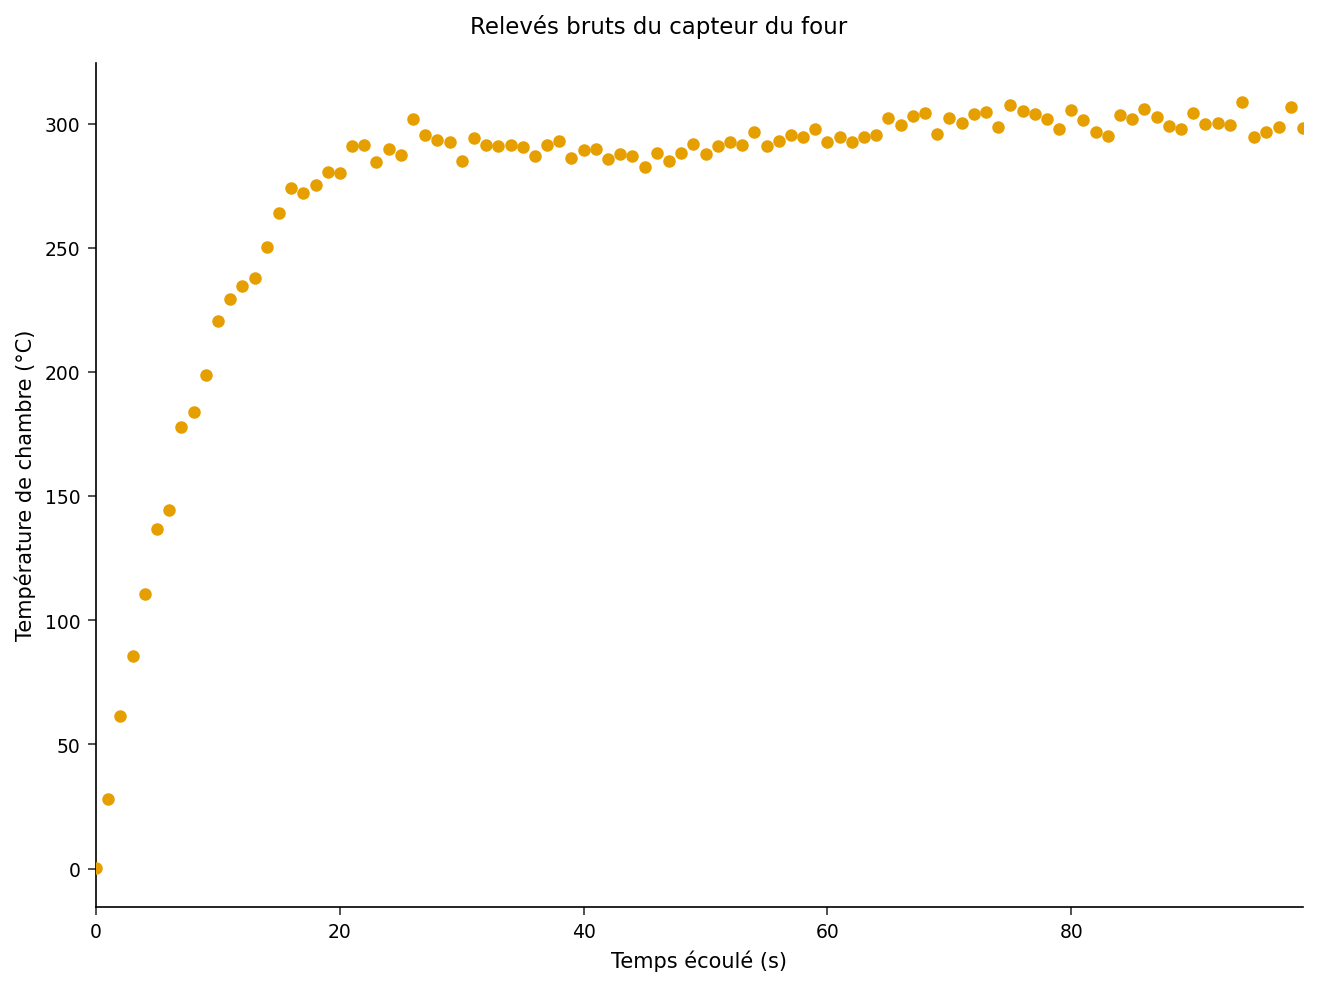

In [2]:
ODS GRAPHICS SUR;

PROCÉDURE SGPLOT DONNÉES=sensor;
    SCATTER x=t y=TEMP / MARKERATTRS=(SYMBOL=circlefilled size=5);
    XAXIS ÉTIQUETTE='Temps écoulé (s)';
    YAXIS ÉTIQUETTE='Température de chambre (°C)';
    TITRE 'Relevés bruts du capteur du four';
EXÉCUTER;

ODS GRAPHICS OFF;

## Étape 3 — Ajuster LOESS avec sélection automatique de la largeur de lissage

Le paramètre de lissage contrôle la largeur de chaque voisinage local : trop petit surajuste le bruit, trop grand efface le dépassement. Plutôt que de deviner, nous laissons LOESS le choisir en minimisant le **critère d'information d'Akaike corrigé** avec `select=AICC`. Nous utilisons des polynômes locaux quadratiques (`degree=2`) afin que la courbe puisse suivre la courbure de la montée en température et du dépassement, et demandons une bande de confiance à 95 % avec `clm` et `alpha=0.05`.

`ODS OUTPUT` capture deux tables sous forme de jeux de données : `OutputStatistics` (valeurs lissées et résidus par point) et `FitSummary` (la largeur sélectionnée et les diagnostics d'ajustement). L'instruction `OUTPUT` écrit un jeu de données `fitted` avec la prédiction, le résidu et les limites de confiance à 95 % pour chaque observation — la matière première des graphiques qui suivent.

In [3]:
PROCÉDURE loess DONNÉES=sensor;
    ODS SORTIE OutputStatistics=loess_fit
               FitSummary=fit_summary;
    ÉTIQUETTE t="Temps (s)" TEMP="Température (°C)";
    MODÈLE TEMP = t / DEGREE=2 SÉLECTIONNER=AICC CLM ALPHA=0.05 details;
    SORTIE out=fitted predicted=temp_hat residual=resid
           lclm=LOWER uclm=UPPER;
EXÉCUTER;

                                         Huit premiers échantillons du capteur                                          


                                                  The LOESS Procedure

Dependent Variable: Température (°C)
Number of Observations: 100
Smoothing Parameter: 0.0800
Degree of Local Polynomials: 2

Fit Summary
-----------
Residual Sum of Squares: 950.859192
Equivalent Number of Parameters: 8.00
AICC: 529.0073
GCV: 11.234159

Output Statistics
Obs        Smoothed     Residual       Fitted
---        --------     --------       ------
1           -0.3394       0.5079      -0.3394
2           30.1685      -1.9751      30.1685
3           58.9327       2.6796      58.9327
4           86.1852      -0.6798      86.1852
5          111.5155      -0.9595     111.5155
6          135.0464       1.5904     135.0464
7          155.9315     -11.6881     155.9315
8          168.9956       8.8330     168.9956
9          184.5066      -0.4446     184.5066
10         202.2409      -3.


NOTE: PROC LOESS data=sensor

NOTE: ODS OUTPUT: OutputStatistics -> loess_fit
NOTE: ODS OUTPUT: FitSummary -> fit_summary
NOTE: Using Python wrapper for LOESS estimation
NOTE: Output dataset fitted has 100 observations
NOTE: ODS OUTPUT: OutputStatistics written to 'loess_fit'.
NOTE: ODS OUTPUT: FitSummary written to 'fit_summary'.


## Étape 4 — Examiner le modèle sélectionné

Le récapitulatif d'ajustement (Fit Summary) enregistre le paramètre de lissage optimal selon l'AICC et la trace de la matrice de prédiction (les degrés de liberté effectifs — une mesure de la complexité du modèle). Un paramètre de lissage plus petit et un DF plus grand signifient un ajustement plus sinueux ; l'AICC équilibre automatiquement l'ajustement et la complexité.

In [4]:
PROCÉDURE IMPRIMER DONNÉES=fit_summary noobs ÉTIQUETTE;
    TITRE "Récapitulatif d'ajustement LOESS (largeur sélectionnée par AICC)";
EXÉCUTER;

                            Récapitulatif d'ajustement LOESS (largeur sélectionnée par AICC)                            

SMOOTHINGPARAMETER                           LABEL1         NVALUE1
              0.08  Residual Sum of Squares          950.8591917253
              0.08  Equivalent Number of Parameters               8
              0.08  Delta1                                        8
              0.08  Delta2                                      7.6
              0.08  Lookup Degrees of Freedom                    92




NOTE: PROC PRINT data=fit_summary

NOTE: PROC PRINT completed: 5 observations printed, 3 variables


## Étape 5 — Superposer l'ajustement et la bande de confiance à la vérité terrain

Comme il s'agit de données simulées, nous avons conservé la colonne `truth` sans bruit. Tracer l'estimation LOESS et sa bande à 95 % à côté de `truth` montre avec quelle fidélité le lisseur a récupéré le signal latent qu'il n'a jamais observé directement.

                            Récapitulatif d'ajustement LOESS (largeur sélectionnée par AICC)                            




NOTE: PROC SORT data=fitted

NOTE: Unlicensed mode - input limited to 100 observations.
NOTE: Read 100 rows from fitted.
NOTE: Wrote fitted (100 rows, 7 columns).
NOTE: PROC SORT statement used.
NOTE: ODS Graphics is ON (width=640px, height=480px, format=SVG).
NOTE: PROC SGPLOT data=fitted

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot1.svg
NOTE: ODS Graphics is OFF.


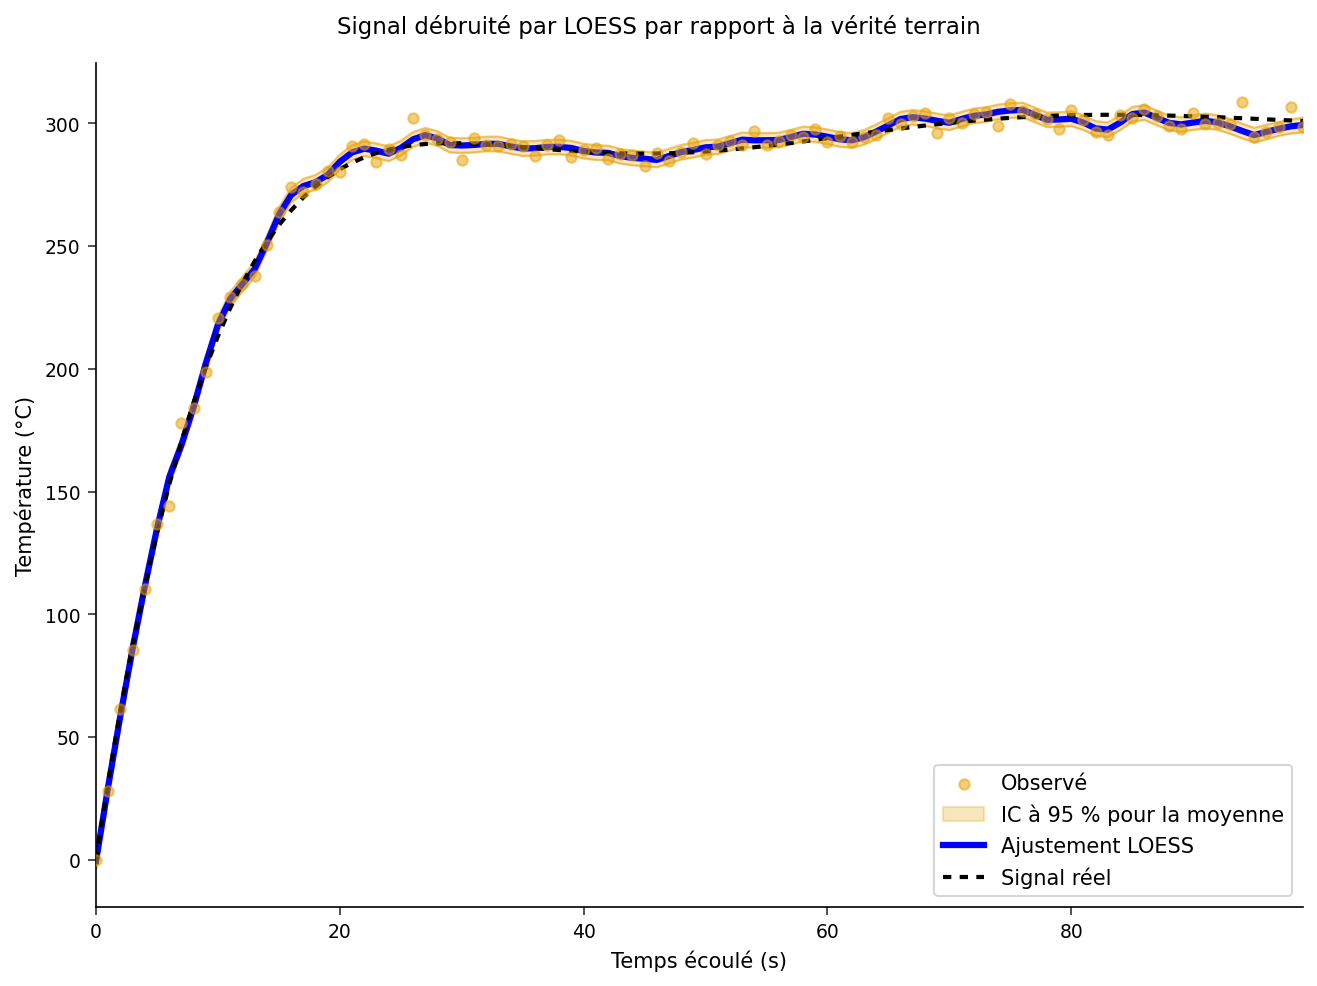

In [5]:
PROCÉDURE TRIER DONNÉES=fitted; PAR t; EXÉCUTER;

ODS GRAPHICS SUR;

PROCÉDURE SGPLOT DONNÉES=fitted;
    SCATTER x=t y=TEMP / MARKERATTRS=(SYMBOL=circlefilled size=5)
            TRANSPARENCY=0.5 legendlabel='Observé';
    BAND x=t LOWER=LOWER UPPER=UPPER / TRANSPARENCY=0.5
         legendlabel='IC à 95 % pour la moyenne';
    SERIES x=t y=temp_hat / LINEATTRS=(thickness=3 color=blue)
           legendlabel='Ajustement LOESS';
    SERIES x=t y=truth / LINEATTRS=(thickness=2 pattern=shortdash color=black)
           legendlabel='Signal réel';
    XAXIS ÉTIQUETTE='Temps écoulé (s)';
    YAXIS ÉTIQUETTE='Température (°C)';
    TITRE 'Signal débruité par LOESS par rapport à la vérité terrain';
EXÉCUTER;

ODS GRAPHICS OFF;

## Étape 6 — Diagnostic des résidus

Les résidus (observé moins ajusté) doivent ressembler à un bruit sans structure centré sur zéro. Toute tendance résiduelle signalerait un sous-lissage ou une caractéristique manquée. Nous traçons les résidus en fonction du temps et résumons leur dispersion — l'écart-type des résidus ressort à 3,10 °C, un peu en dessous du bruit de 4 °C que nous avons injecté car l'ajustement local en absorbe une petite part.

                            Récapitulatif d'ajustement LOESS (largeur sélectionnée par AICC)                            

                                  Récapitulatif des résidus (bruit de mesure récupéré)                                  

                                                  The MEANS Procedure

 Variable  Label                 N        Mean     Std Dev     Minimum     Maximum
 ---------------------------------------------------------------------------------
 RESID     Résidu (°C)         100       0.139       3.096     -11.688      11.909
 ---------------------------------------------------------------------------------




NOTE: ODS Graphics is ON (width=640px, height=480px, format=SVG).
NOTE: PROC SGPLOT data=fitted

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot2.svg
NOTE: ODS Graphics is OFF.
NOTE: PROC MEANS
NOTE: PROC MEANS statement used.


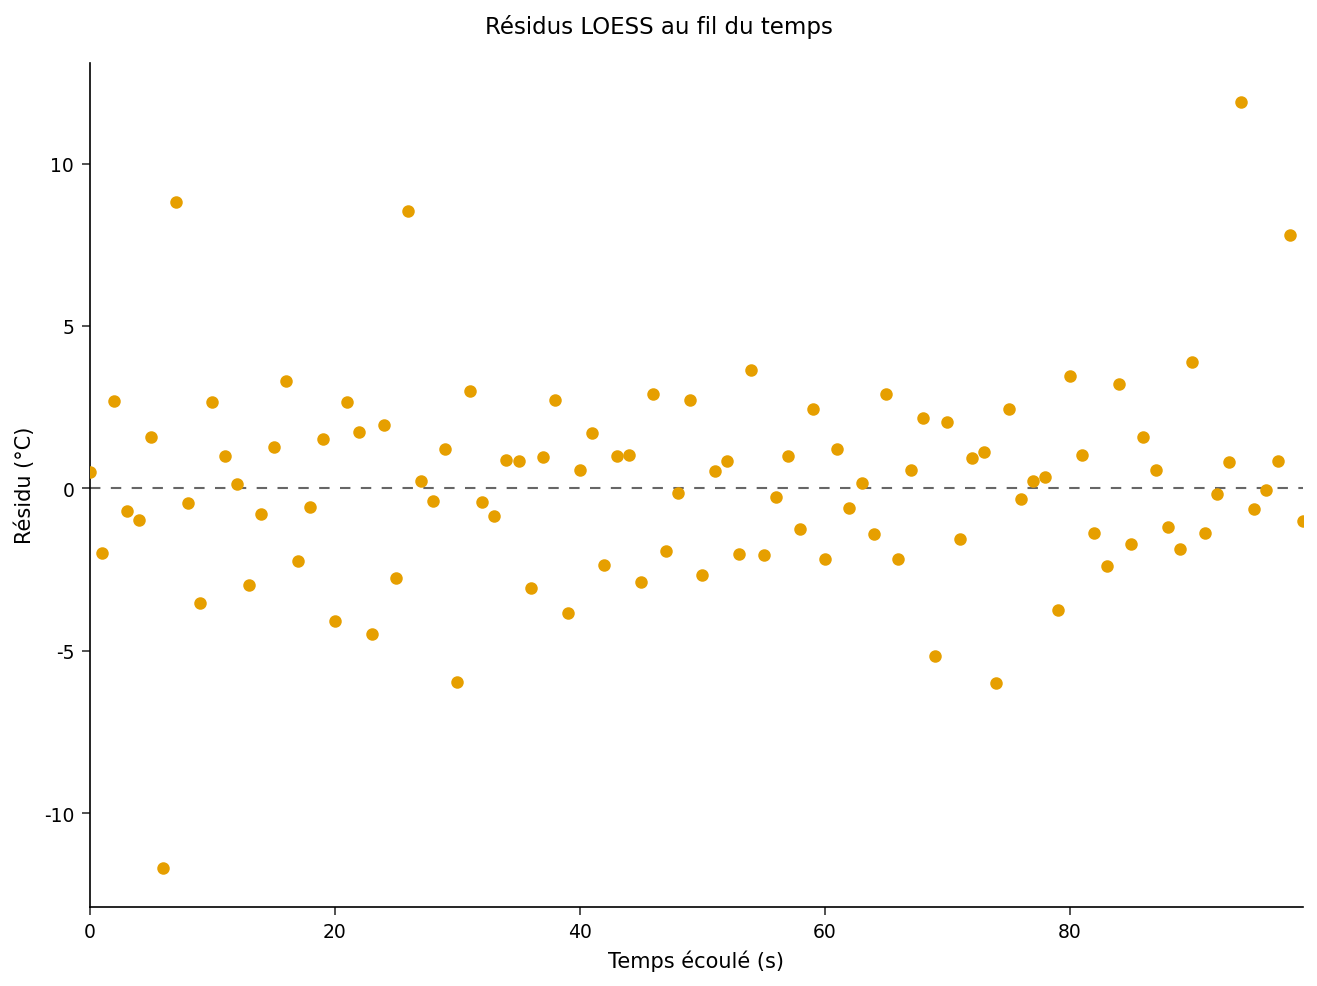

In [6]:
ODS GRAPHICS SUR;

PROCÉDURE SGPLOT DONNÉES=fitted;
    REFLINE 0 / AXIS=y LINEATTRS=(pattern=shortdash);
    SCATTER x=t y=resid / MARKERATTRS=(SYMBOL=circlefilled size=5);
    XAXIS ÉTIQUETTE='Temps écoulé (s)';
    YAXIS ÉTIQUETTE='Résidu (°C)';
    TITRE 'Résidus LOESS au fil du temps';
EXÉCUTER;

ODS GRAPHICS OFF;

PROCÉDURE MOYENNES DONNÉES=fitted n mean std MIN MAX maxdec=3;
    VAR resid;
    ÉTIQUETTE resid="Résidu (°C)";
    TITRE 'Récapitulatif des résidus (bruit de mesure récupéré)';
EXÉCUTER;

## Étape 7 — Évaluer une grille de surveillance régulière pour la MSP

Les horodatages du capteur n'ont pas besoin d'être régulièrement espacés, mais une carte de contrôle veut le signal à une cadence fixe. Nous construisons une grille temporelle uniforme de 60 points et appliquons le modèle LOESS ajusté avec l'instruction `SCORE`, en demandant des limites de confiance. Les valeurs évaluées forment un signal propre, régulièrement espacé, prêt à alimenter une routine de maîtrise statistique des procédés (MSP).

In [7]:
DONNÉES grid;
    FAIRE t = 0 JUSQU_À 99 PAR 99/59;
        SORTIE;
    FIN;
EXÉCUTER;

PROCÉDURE loess DONNÉES=sensor;
    ÉTIQUETTE t="Temps (s)" TEMP="Température (°C)";
    MODÈLE TEMP = t / DEGREE=2 SÉLECTIONNER=AICC CLM ALPHA=0.05;
    SCORE DONNÉES=grid CLM IMPRIMER;
    TITRE 'LOESS évalué sur une grille de surveillance uniforme';
EXÉCUTER;

                                  Récapitulatif des résidus (bruit de mesure récupéré)                                  


                                                  The LOESS Procedure

Dependent Variable: Température (°C)
Number of Observations: 100
Smoothing Parameter: 0.0800
Degree of Local Polynomials: 2

Fit Summary
-----------
Residual Sum of Squares: 950.859192
Equivalent Number of Parameters: 8.00
AICC: 529.0073
GCV: 11.234159

Output Statistics
Obs        Smoothed     Residual       Fitted
---        --------     --------       ------
1           -0.3394       0.5079      -0.3394
2           30.1685      -1.9751      30.1685
3           58.9327       2.6796      58.9327
4           86.1852      -0.6798      86.1852
5          111.5155      -0.9595     111.5155
6          135.0464       1.5904     135.0464
7          155.9315     -11.6881     155.9315
8          168.9956       8.8330     168.9956
9          184.5066      -0.4446     184.5066
10         202.2409      -3.


NOTE: DATA grid


NOTE: Wrote grid (60 rows, 1 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: PROC LOESS data=sensor

NOTE: Using Python wrapper for LOESS estimation
NOTE: ODS OUTPUT: OutputStatistics written to 'loess_fit'.
NOTE: ODS OUTPUT: FitSummary written to 'fit_summary'.


## Étape 8 — Quantifier le débruitage

Enfin, nous comparons le signal brut et l'estimation LOESS à la vérité connue. L'erreur quadratique moyenne du signal lissé devrait être bien plus faible que celle des relevés bruts, confirmant que LOESS a retiré le bruit de mesure tout en préservant la montée en température et le dépassement.

In [8]:
DONNÉES accuracy;
    DÉFINIR fitted;
    raw_sq_err   = (TEMP     - truth)**2;
    loess_sq_err = (temp_hat - truth)**2;
EXÉCUTER;

PROCÉDURE MOYENNES DONNÉES=accuracy mean maxdec=3;
    VAR raw_sq_err loess_sq_err;
    ÉTIQUETTE raw_sq_err   = 'EQM des relevés bruts vs vérité'
          loess_sq_err = 'EQM ajustement LOESS vs vérité';
    TITRE 'Performance de débruitage : brut vs LOESS';
EXÉCUTER;

                                       Performance de débruitage : brut vs LOESS                                        

                                                  The MEANS Procedure

 Variable      Label                                        Mean
 ---------------------------------------------------------------
 raw_sq_err    EQM des relevés bruts vs vérité            14.774
 loess_sq_err  EQM ajustement LOESS vs vérité              6.629
 ---------------------------------------------------------------




NOTE: DATA accuracy


NOTE: Read 100 rows from fitted.
NOTE: Wrote accuracy (100 rows, 9 columns).
NOTE: DATA elapsed:
  wall  0.01 seconds
  cpu   0.01 seconds
NOTE: PROC MEANS
NOTE: PROC MEANS statement used.


## Interprétation des résultats

- **Largeur automatique.** `select=AICC` a choisi un paramètre de lissage de **0,08** sans réglage manuel, impliquant environ **8 paramètres équivalents** — assez de flexibilité locale pour suivre la montée, le dépassement et le creux, tout en lissant le bruit.
- **Récupération fidèle.** La courbe ajustée suit fidèlement le signal latent `truth` le long de la montée, du pic de dépassement près de t = 28, et de la traîne de stabilisation, démontrant que LOESS a récupéré un signal non linéaire arbitraire sans hypothèse paramétrique.
- **Résidus propres.** Les résidus se dispersent autour de zéro avec un écart-type de **3,10 °C** (moyenne 0,14, plage −11,7 à 11,9) et ne montrent aucune tendance temporelle résiduelle — preuve que le modèle n'est ni sur-lissé ni sous-lissé.
- **Débruitage mesurable.** Par rapport à la vérité terrain, l'estimation LOESS réduit l'erreur quadratique moyenne (EQM) de **14,77** (relevés bruts) à **6,63** — une réduction de 55 %, le gain principal pour la surveillance du procédé.
- **Sortie prête pour la MSP.** L'étape `SCORE` a produit le signal débruité sur une grille uniforme de 60 points avec des limites de confiance, exactement la forme qu'une carte de contrôle en aval consomme.

**À retenir :** Lorsqu'un capteur de procédé produit un signal lisse mais bruité de forme inconnue, PROC LOESS est un moyen à faibles hypothèses et auto-ajustable pour extraire la tendance sous-jacente, y attacher des bornes d'incertitude, et le rééchantillonner sur une grille de surveillance — le tout sans s'engager sur un modèle paramétrique que la physique ne justifierait pas.